# Lekcja 13: SQL – zapytania i łączenia

# 1. Wprowadzenie do SQL i relacyjnych baz danych

In [3]:
# Przykład 2: SQL vs Pandas – porównanie składni

import pandas as pd
import sqlite3

# Pandas approach
df_customers = pd.DataFrame({
    'customer_id': [1, 2, 3],
    'name': ['Jan Kowalski', 'Anna Nowak', 'Piotr Wiśniewski'],
    'city': ['Warszawa', 'Kraków', 'Gdańsk'],
    'age': [28, 35, 42]
})

# Filtrowanie w Pandas
young_customers = df_customers[df_customers['age'] < 40]
print("Pandas - młodzi klienci:")
print(young_customers)

# SQL approach (SQLite w pamięci)
conn = sqlite3.connect(':memory:')
df_customers.to_sql('customers', conn, index=False)

# To samo zapytanie w SQL
query = """
SELECT *
FROM customers
WHERE age < 40
"""
sql_result = pd.read_sql_query(query, conn)
print("\nSQL - młodzi klienci:")
print(sql_result)

conn.close()

Pandas - młodzi klienci:
   customer_id          name      city  age
0            1  Jan Kowalski  Warszawa   28
1            2    Anna Nowak    Kraków   35

SQL - młodzi klienci:
   customer_id          name      city  age
0            1  Jan Kowalski  Warszawa   28
1            2    Anna Nowak    Kraków   35


In [5]:
# Przykład 3: Tworzenie prostej bazy SQLite z Pythona

import sqlite3
import pandas as pd

# Tworzymy bazę danych (plik na dysku)
conn = sqlite3.connect('sklep.db')
cursor = conn.cursor()

# Tworzymy tabelę klientów
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    email TEXT UNIQUE,
    city TEXT,
    registration_date DATE
)
''')

# Wstawiamy przykładowe dane
customers_data = [
    (1, 'Jan Kowalski', 'jan@email.com', 'Warszawa', '2024-01-10'),
    (2, 'Anna Nowak', 'anna@email.com', 'Kraków', '2024-01-12'),
    (3, 'Piotr Wiśniewski', 'piotr@email.com', 'Gdańsk', '2024-01-15')
]

cursor.executemany('''
INSERT OR REPLACE INTO customers (customer_id, name, email, city, 
registration_date)
VALUES (?, ?, ?, ?, ?)
''', customers_data)

# Zapisujemy zmiany
conn.commit()

# Odczytujemy dane
df = pd.read_sql_query("SELECT * FROM customers", conn)
print(df)

conn.close()

   customer_id              name            email      city registration_date
0            1      Jan Kowalski    jan@email.com  Warszawa        2024-01-10
1            2        Anna Nowak   anna@email.com    Kraków        2024-01-12
2            3  Piotr Wiśniewski  piotr@email.com    Gdańsk        2024-01-15


# 2. SELECT – podstawowe zapytania

In [6]:
# Przykład 1: Podstawowe SELECT – wybór kolumn

import sqlite3
import pandas as pd

# Tworzymy przykładową bazę z produktami
conn = sqlite3.connect(':memory:')
products = pd.DataFrame({
    'product_id': [1, 2, 3, 4, 5],
    'name': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki'],
    'category': ['Elektronika', 'Akcesoria', 'Akcesoria', 'Elektronika', 
'Akcesoria'],
    'price': [3500, 50, 200, 1200, 150],
    'stock': [10, 150, 80, 25, 60]
})

products.to_sql('products', conn, index=False)

# Zapytanie 1: Wszystkie kolumny
query1 = "SELECT * FROM products"
print("Wszystkie produkty:")
print(pd.read_sql_query(query1, conn))

# Zapytanie 2: Wybrane kolumny
query2 = "SELECT name, price FROM products"
print("\nSamo nazwa i cena:")
print(pd.read_sql_query(query2, conn))

# Zapytanie 3: Obliczenia w SELECT
query3 = """
SELECT
    name,
    price,
    price * 1.23 AS price_with_vat,
    stock * price AS inventory_value
FROM products
"""
print("\nCena z VAT i wartość zapasów:")
print(pd.read_sql_query(query3, conn))

conn.close()

Wszystkie produkty:
   product_id        name     category  price  stock
0           1      Laptop  Elektronika   3500     10
1           2        Mysz    Akcesoria     50    150
2           3  Klawiatura    Akcesoria    200     80
3           4     Monitor  Elektronika   1200     25
4           5   Słuchawki    Akcesoria    150     60

Samo nazwa i cena:
         name  price
0      Laptop   3500
1        Mysz     50
2  Klawiatura    200
3     Monitor   1200
4   Słuchawki    150

Cena z VAT i wartość zapasów:
         name  price  price_with_vat  inventory_value
0      Laptop   3500          4305.0            35000
1        Mysz     50            61.5             7500
2  Klawiatura    200           246.0            16000
3     Monitor   1200          1476.0            30000
4   Słuchawki    150           184.5             9000


In [7]:
# Przykład 2: WHERE – filtrowanie danych

import sqlite3
import pandas as pd
conn = sqlite3.connect(':memory:')

# Dataset: Titanic (subset)
titanic = pd.DataFrame({
'passenger_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'name': ['Braund', 'Cumings', 'Heikkinen', 'Futrelle', 'Allen', 'Moran', 
'McCarthy', 'Palsson'],
    'age': [22, 38, 26, 35, 35, None, 54, 2],
    'sex': ['male', 'female', 'female', 'female', 'male', 'male', 'male', 
'male'],
    'survived': [0, 1, 1, 1, 0, 0, 0, 0],
    'pclass': [3, 1, 3, 1, 3, 3, 1, 3],
    'fare': [7.25, 71.28, 7.92, 53.10, 8.05, 8.46, 51.86, 21.08]
})

titanic.to_sql('titanic', conn, index=False)

# Zapytanie 1: Prości filtr
query1 = """
SELECT name, age, sex, survived
FROM titanic
WHERE survived = 1
"""
print("Ocaleni pasażerowie:")
print(pd.read_sql_query(query1, conn))

# Zapytanie 2: Złożone warunki (AND, OR)
query2 = """
SELECT name, age, sex, pclass, fare
FROM titanic
WHERE (sex = 'female' AND pclass = 1) OR fare > 50
"""
print("\nKobiety z 1 klasy LUB bilet > 50:")
print(pd.read_sql_query(query2, conn))

# Zapytanie 3: Zakres wartości (BETWEEN)
query3 = """
SELECT name, age, fare
FROM titanic
WHERE age BETWEEN 20 AND 40
AND fare < 20
"""
print("\nWiek 20-40 i tani bilet:")
print(pd.read_sql_query(query3, conn))

# Zapytanie 4: Lista wartości (IN)
query4 = """
SELECT name, pclass, fare
FROM titanic
WHERE pclass IN (1, 2)
ORDER BY fare DESC
"""
print("\nKlasa 1 lub 2, sortowane po cenie:")
print(pd.read_sql_query(query4, conn))

conn.close()


Ocaleni pasażerowie:
        name   age     sex  survived
0    Cumings  38.0  female         1
1  Heikkinen  26.0  female         1
2   Futrelle  35.0  female         1

Kobiety z 1 klasy LUB bilet > 50:
       name   age     sex  pclass   fare
0   Cumings  38.0  female       1  71.28
1  Futrelle  35.0  female       1  53.10
2  McCarthy  54.0    male       1  51.86

Wiek 20-40 i tani bilet:
        name   age  fare
0     Braund  22.0  7.25
1  Heikkinen  26.0  7.92
2      Allen  35.0  8.05

Klasa 1 lub 2, sortowane po cenie:
       name  pclass   fare
0   Cumings       1  71.28
1  Futrelle       1  53.10
2  McCarthy       1  51.86


In [8]:
# Przykład 3: ORDER BY i LIMIT – sortowanie i ograniczanie wyników

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

# California Housing (subset dla przykładu)
housing = pd.DataFrame({
    'id': range(1, 11),
    'median_income': [8.3, 8.3, 7.3, 5.6, 3.8, 4.0, 3.7, 3.5, 3.2, 2.9],
    'median_house_value': [452600, 358500, 352100, 341300, 342200, 269700, 299200, 241400, 226700, 261100],
    'total_rooms': [880, 7099, 1467, 1274, 1627, 919, 1022, 850, 1665, 1284],
    'population': [322, 2401, 496, 558, 565, 413, 372, 341, 845, 341],
    'latitude': [37.88, 37.86, 37.85, 37.85, 37.85, 37.84, 37.84, 37.84, 37.84, 37.83],
    'longitude': [-122.23, -122.22, -122.24, -122.25, -122.25, -122.25, -122.25, -122.26, -122.25, -122.27]
})
housing.to_sql('housing', conn, index=False)

# Zapytanie 1: TOP 5 najdroższych domów
query1 = """
SELECT id, median_income, median_house_value
FROM housing
ORDER BY median_house_value DESC
LIMIT 5
"""
print("TOP 5 najdroższych:")
print(pd.read_sql_query(query1, conn))

# Zapytanie 2: Sortowanie po wielu kolumnach
query2 = """
SELECT id, median_income, median_house_value, total_rooms
FROM housing
ORDER BY median_income DESC, total_rooms ASC
LIMIT 7
"""
print("\nSortowane: income DESC, potem rooms ASC:")
print(pd.read_sql_query(query2, conn))

# Zapytanie 3: OFFSET (pomijanie wyników) – paginacja
query3 = """
SELECT id, median_house_value
FROM housing
ORDER BY median_house_value DESC
LIMIT 3 OFFSET 3
"""
print("\nWyniki 4-6 (pomijamy 3 pierwsze):")
print(pd.read_sql_query(query3, conn))

conn.close()

TOP 5 najdroższych:
   id  median_income  median_house_value
0   1            8.3              452600
1   2            8.3              358500
2   3            7.3              352100
3   5            3.8              342200
4   4            5.6              341300

Sortowane: income DESC, potem rooms ASC:
   id  median_income  median_house_value  total_rooms
0   1            8.3              452600          880
1   2            8.3              358500         7099
2   3            7.3              352100         1467
3   4            5.6              341300         1274
4   6            4.0              269700          919
5   5            3.8              342200         1627
6   7            3.7              299200         1022

Wyniki 4-6 (pomijamy 3 pierwsze):
   id  median_house_value
0   5              342200
1   4              341300
2   7              299200


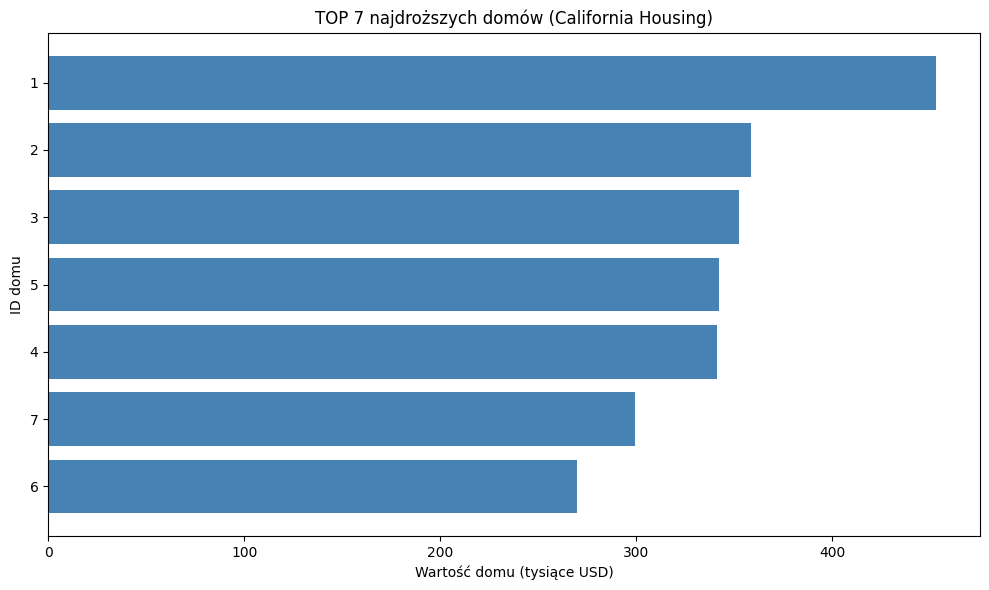

In [9]:
# Wizualizacja: Porównanie najdroższych domów

import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
housing = pd.DataFrame({
    'id': range(1, 11),
    'median_income': [8.3, 8.3, 7.3, 5.6, 3.8, 4.0, 3.7, 3.5, 3.2, 2.9],
    'median_house_value': [452600, 358500, 352100, 341300, 342200, 269700, 299200, 241400, 226700, 261100],
})
housing.to_sql('housing', conn, index=False)

# Zapytanie: TOP 7 według wartości
query = """
SELECT id, median_income, median_house_value
FROM housing
ORDER BY median_house_value DESC
LIMIT 7
"""
top_houses = pd.read_sql_query(query, conn)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
plt.barh(top_houses['id'].astype(str), top_houses['median_house_value'] / 
1000, color='steelblue')
plt.xlabel('Wartość domu (tysiące USD)')
plt.ylabel('ID domu')
plt.title('TOP 7 najdroższych domów (California Housing)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

conn.close()


# 3. JOIN – łączenie tabel

In [ ]:
# Przykład 1: INNER JOIN – łączenie klientów z zamówieniami

import sqlite3
import pandas as pd
conn = sqlite3.connect(':memory:')

# Tabela klientów
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Jan Kowalski', 'Anna Nowak', 'Piotr Wiśniewski', 'Maria Zając'],
    'city': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław']
})

# Tabela zamówień
orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105],
    'customer_id': [1, 2, 1, 3, 1],
    'order_date': ['2024-01-10', '2024-01-11', '2024-01-12', '2024-01-13', '2024-01-14'],
    'total_amount': [250.0, 120.5, 340.0, 80.0, 190.0]
})
customers.to_sql('customers', conn, index=False)
orders.to_sql('orders', conn, index=False)

# INNER JOIN – tylko klienci którzy złożyli zamówienie
query = """
SELECT
    c.customer_id,
    c.name,
    c.city,
    o.order_id,
    o.order_date,
    o.total_amount
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
ORDER BY c.customer_id, o.order_date
"""
result = pd.read_sql_query(query, conn)
print("INNER JOIN - klienci z zamówieniami:")
print(result)

# Podsumowanie zamówień na klienta
query2 = """
SELECT
    c.name,
    COUNT(o.order_id) AS number_of_orders,
    SUM(o.total_amount) AS total_spent
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name
ORDER BY total_spent DESC
"""
print("\nPodsumowanie zamówień:")
print(pd.read_sql_query(query2, conn))

conn.close()


INNER JOIN - klienci z zamówieniami:
   customer_id              name      city  order_id  order_date  total_amount
0            1      Jan Kowalski  Warszawa       101  2024-01-10         250.0
1            1      Jan Kowalski  Warszawa       103  2024-01-12         340.0
2            1      Jan Kowalski  Warszawa       105  2024-01-14         190.0
3            2        Anna Nowak    Kraków       102  2024-01-11         120.5
4            3  Piotr Wiśniewski    Gdańsk       104  2024-01-13          80.0

Podsumowanie zamówień:
               name  number_of_orders  total_spent
0      Jan Kowalski                 3        780.0
1        Anna Nowak                 1        120.5
2  Piotr Wiśniewski                 1         80.0


In [11]:
# Przykład 2: LEFT JOIN – klienci bez zamówień

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

customers = pd.DataFrame({
'customer_id': [1, 2, 3, 4],
    'name': ['Jan Kowalski', 'Anna Nowak', 'Piotr Wiśniewski', 'Maria Zając'],
    'city': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław']
})

orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105],
    'customer_id': [1, 2, 1, 3, 1],
    'order_date': ['2024-01-10', '2024-01-11', '2024-01-12', '2024-01-13', 
'2024-01-14'],
    'total_amount': [250.0, 120.5, 340.0, 80.0, 190.0]
})
customers.to_sql('customers', conn, index=False)
orders.to_sql('orders', conn, index=False)

# LEFT JOIN - wszyscy klienci (nawet bez zamówień)
query = """
SELECT
    c.customer_id,
    c.name,
    c.city,
    COUNT(o.order_id) AS number_of_orders,
    COALESCE(SUM(o.total_amount), 0) AS total_spent
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name, c.city
ORDER BY total_spent DESC
"""
result = pd.read_sql_query(query, conn)
print("LEFT JOIN - wszyscy klienci:")
print(result)

# Wykrycie klientów bez zamówień
query2 = """
SELECT
    c.customer_id,
    c.name,
    c.city
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
WHERE o.order_id IS NULL
"""
print("\nKlienci BEZ zamówień:")
print(pd.read_sql_query(query2, conn))

conn.close()

LEFT JOIN - wszyscy klienci:
   customer_id              name      city  number_of_orders  total_spent
0            1      Jan Kowalski  Warszawa                 3        780.0
1            2        Anna Nowak    Kraków                 1        120.5
2            3  Piotr Wiśniewski    Gdańsk                 1         80.0
3            4       Maria Zając   Wrocław                 0          0.0

Klienci BEZ zamówień:
   customer_id         name     city
0            4  Maria Zając  Wrocław


In [12]:
# Przykład 3: Złożony JOIN z 3 tabelami – sklep online

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

# Klienci
customers = pd.DataFrame({
    'customer_id': [1, 2, 3],
    'name': ['Jan', 'Anna', 'Piotr']
})

# Zamówienia
orders = pd.DataFrame({
    'order_id': [101, 102, 103],
    'customer_id': [1, 2, 1],
    'order_date': ['2024-01-10', '2024-01-11', '2024-01-12']
})

# Pozycje zamówień (order items)
order_items = pd.DataFrame({
    'item_id': [1, 2, 3, 4, 5],
    'order_id': [101, 101, 102, 103, 103],
    'product_name': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki'],
    'quantity': [1, 2, 1, 1, 1],
    'price': [3500, 50, 200, 1200, 150]
})

customers.to_sql('customers', conn, index=False)
orders.to_sql('orders', conn, index=False)
order_items.to_sql('order_items', conn, index=False)

# JOIN 3 tabel
query = """
SELECT
    c.name AS customer_name,
    o.order_id,
    o.order_date,
    oi.product_name,
    oi.quantity,
    oi.price,
    (oi.quantity * oi.price) AS item_total
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
ORDER BY c.name, o.order_id, oi.item_id
"""
result = pd.read_sql_query(query, conn)
print("Szczegóły zamówień (3 tabele):")
print(result)

# Łączna wartość zamówienia dla każdego klienta
query2 = """
SELECT
    c.name,
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(oi.quantity * oi.price) AS total_spent
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_id, c.name
ORDER BY total_spent DESC
"""
print("\nPodsumowanie wydatków:")
print(pd.read_sql_query(query2, conn))

conn.close()


Szczegóły zamówień (3 tabele):
  customer_name  order_id  order_date product_name  quantity  price  \
0          Anna       102  2024-01-11   Klawiatura         1    200   
1           Jan       101  2024-01-10       Laptop         1   3500   
2           Jan       101  2024-01-10         Mysz         2     50   
3           Jan       103  2024-01-12      Monitor         1   1200   
4           Jan       103  2024-01-12    Słuchawki         1    150   

   item_total  
0         200  
1        3500  
2         100  
3        1200  
4         150  

Podsumowanie wydatków:
   name  total_orders  total_spent
0   Jan             2         4950
1  Anna             1          200


# 4. GROUP BY – grupowanie i agregacje

In [13]:
# Przykład 1: Podstawowe agregacje – sprzedaż według kategorii

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

# Tabela sprzedaży
sales = pd.DataFrame({
    'sale_id': range(1, 11),
    'product': ['Laptop', 'Laptop', 'Mysz', 'Klawiatura', 'Monitor',
                'Laptop', 'Mysz', 'Monitor', 'Słuchawki', 'Klawiatura'],
    'category': ['Elektronika', 'Elektronika', 'Akcesoria', 'Akcesoria', 'Elektronika',
                 'Elektronika', 'Akcesoria', 'Elektronika', 'Akcesoria', 'Akcesoria'],
    'quantity': [1, 2, 5, 3, 1, 1, 10, 2, 4, 2],
    'revenue': [3500, 7000, 250, 600, 1200, 3500, 500, 2400, 600, 400]
})
sales.to_sql('sales', conn, index=False)

# GROUP BY kategoria
query1 = """
SELECT
    category,
    COUNT(*) AS number_of_sales,
    SUM(quantity) AS total_quantity,
    SUM(revenue) AS total_revenue,
    AVG(revenue) AS avg_revenue,
    MIN(revenue) AS min_revenue,
    MAX(revenue) AS max_revenue
    FROM sales
GROUP BY category
ORDER BY total_revenue DESC
"""
print("Agregacje według kategorii:")
print(pd.read_sql_query(query1, conn))

# GROUP BY produkt
query2 = """
SELECT
    product,
    COUNT(*) AS times_sold,
    SUM(quantity) AS total_units,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC
LIMIT 5
"""
print("\nTOP 5 produktów:")
print(pd.read_sql_query(query2, conn))

conn.close()


Agregacje według kategorii:
      category  number_of_sales  total_quantity  total_revenue  avg_revenue  \
0  Elektronika                5               7          17600       3520.0   
1    Akcesoria                5              24           2350        470.0   

   min_revenue  max_revenue  
0         1200         7000  
1          250          600  

TOP 5 produktów:
      product  times_sold  total_units  total_revenue
0      Laptop           3            4          14000
1     Monitor           2            3           3600
2  Klawiatura           2            5           1000
3        Mysz           2           15            750
4   Słuchawki           1            4            600


In [14]:
# Przykład 2: HAVING – filtrowanie grup (WHERE dla agregacji)

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

# Dane sprzedażowe
sales = pd.DataFrame({
    'sale_id': range(1, 21),
    'product': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki'] * 4,
    'category': (['Elektronika'] * 2 + ['Akcesoria'] * 3) * 4,
    'revenue': [3500, 50, 200, 1200, 150,
                3600, 45, 210, 1250, 140,
                3400, 55, 190, 1180, 160,
                3550, 48, 205, 1220, 155]
})
sales.to_sql('sales', conn, index=False)

# HAVING - tylko produkty z przychdem > 1000
query = """
SELECT
    product,
    COUNT(*) AS number_of_sales,
    SUM(revenue) AS total_revenue,
    AVG(revenue) AS avg_revenue
FROM sales
GROUP BY product
HAVING SUM(revenue) > 1000
ORDER BY total_revenue DESC
"""
print("Produkty z przychodem > 1000:")
print(pd.read_sql_query(query, conn))

# HAVING z wieloma warunkami
query2 = """
SELECT
    product,
    COUNT(*) AS sales_count,
    AVG(revenue) AS avg_revenue
FROM sales
GROUP BY product
HAVING COUNT(*) >= 3 AND AVG(revenue) > 500
ORDER BY avg_revenue DESC
"""
print("\n>= 3 sprzedaży i średnia > 500:")
print(pd.read_sql_query(query2, conn))

conn.close()

Produkty z przychodem > 1000:
   product  number_of_sales  total_revenue  avg_revenue
0   Laptop                4          14050       3512.5
1  Monitor                4           4850       1212.5

>= 3 sprzedaży i średnia > 500:
   product  sales_count  avg_revenue
0   Laptop            4       3512.5
1  Monitor            4       1212.5


Sprzedaż: miesiąc x kategoria:
     month     category  sales_count  total_revenue
0  2024-01    Akcesoria            2            450
1  2024-01  Elektronika            2           4700
2  2024-02    Akcesoria            1            300
3  2024-02  Elektronika            3           6070
4  2024-03    Akcesoria            2            570
5  2024-03  Elektronika            2           4580


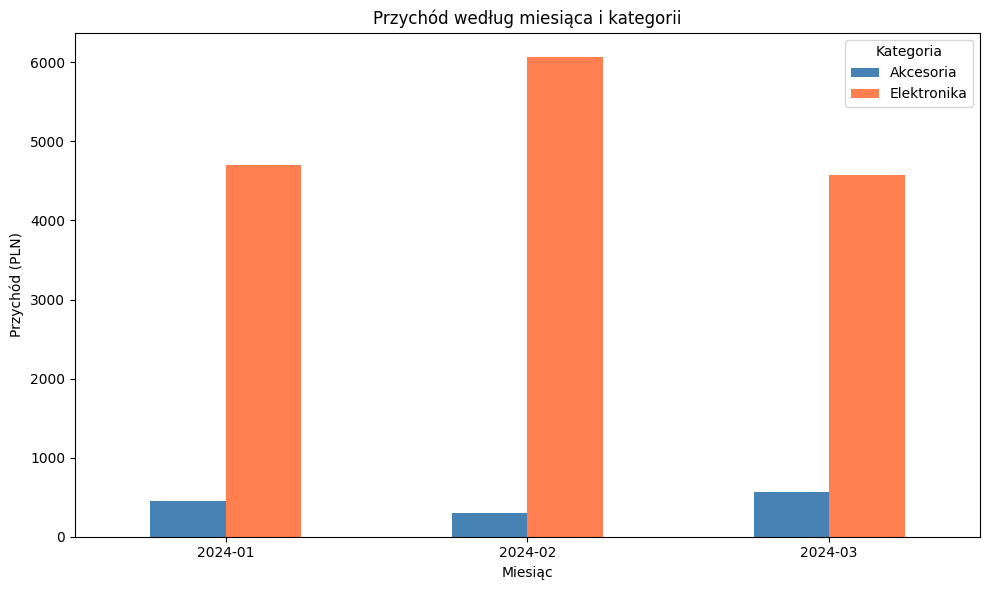

In [15]:
# Przykład 3: Grupowanie po wielu kolumnach + wykres

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect(':memory:')

# Dane sprzedażowe z datami
sales = pd.DataFrame({
    'date': ['2024-01', '2024-01', '2024-01', '2024-02', '2024-02', '2024-02',
             '2024-03', '2024-03', '2024-03', '2024-01', '2024-02', '2024-03'],
    'category': ['Elektronika', 'Akcesoria', 'Elektronika', 'Elektronika',
                 'Akcesoria', 'Elektronika',
                 'Elektronika', 'Akcesoria', 'Elektronika', 'Akcesoria', 'Elektronika', 'Akcesoria'],
    'revenue': [3500, 250, 1200, 3600, 300, 1250, 3400, 280, 1180, 200, 1220, 290]
})
sales.to_sql('sales', conn, index=False)

# GROUP BY miesiąc + kategoria
query = """
SELECT
    date AS month,
    category,
    COUNT(*) AS sales_count,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY date, category
ORDER BY date, category
"""
result = pd.read_sql_query(query, conn)
print("Sprzedaż: miesiąc x kategoria:")
print(result)

# Wizualizacja
pivot_data = result.pivot(index='month', columns='category', 
values='total_revenue').fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
pivot_data.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Przychód (PLN)')
ax.set_title('Przychód według miesiąca i kategorii')
ax.legend(title='Kategoria')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

conn.close()

# 5. Indeksy – optymalizacja wydajności

In [16]:
# Przykład 1: Wpływ indeksu na wydajność

import sqlite3
import pandas as pd
import time

conn = sqlite3.connect(':memory:')

# Tworzymy dużą tabelę (50k wierszy)
import numpy as np

np.random.seed(42)

large_data = pd.DataFrame({
    'user_id': range(1, 50001),
    'name': [f'User_{i}' for i in range(1, 50001)],
    'age': np.random.randint(18, 80, 50000),
    'city': np.random.choice(['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Poznań'], 50000),
    'registration_date': pd.date_range('2020-01-01', periods=50000, freq='15min')
})
large_data.to_sql('users', conn, index=False)

# Test 1: BEZ indeksu
start = time.time()
query = "SELECT * FROM users WHERE age > 60 ORDER BY registration_date DESC LIMIT 100"
result1 = pd.read_sql_query(query, conn)
time_without_index = time.time() - start
print(f"Czas BEZ indeksu: {time_without_index:.4f} s")

# Tworzenie indeksów
conn.execute("CREATE INDEX idx_age ON users(age)")
conn.execute("CREATE INDEX idx_registration_date ON users(registration_date)")

# Test 2: Z indeksem
start = time.time()
result2 = pd.read_sql_query(query, conn)
time_with_index = time.time() - start
print(f"Czas Z indeksem: {time_with_index:.4f} s")
print(f"\nPrzyśpieszenie: {time_without_index / time_with_index:.1f}x")

# Wyświetlenie wyników
print("\nPierwsze 5 wyników:")
print(result2.head())

conn.close()

Czas BEZ indeksu: 0.0074 s
Czas Z indeksem: 0.0008 s

Przyśpieszenie: 9.9x

Pierwsze 5 wyników:
   user_id        name  age     city    registration_date
0    50000  User_50000   70   Gdańsk  2021-06-04 19:45:00
1    49993  User_49993   72   Kraków  2021-06-04 18:00:00
2    49991  User_49991   72   Gdańsk  2021-06-04 17:30:00
3    49990  User_49990   71  Wrocław  2021-06-04 17:15:00
4    49981  User_49981   72   Poznań  2021-06-04 15:00:00


In [17]:
# Przykład 2: Indeks na kluczu obcym (JOIN)

import sqlite3
import pandas as pd
import time

conn = sqlite3.connect(':memory:')

# Duże tabele dla realistycznego testu
customers = pd.DataFrame({
'customer_id': range(1, 10001),
    'name': [f'Customer_{i}' for i in range(1, 10001)],
    'city': ['Warszawa'] * 10000
})

import numpy as np

np.random.seed(42)
orders = pd.DataFrame({
    'order_id': range(1, 50001),
    'customer_id': np.random.randint(1, 10001, 50000),
    'amount': np.random.uniform(10, 1000, 50000)
})
customers.to_sql('customers', conn, index=False)
orders.to_sql('orders', conn, index=False)

# JOIN BEZ indeksu
start = time.time()
query = """
SELECT c.name, COUNT(o.order_id) AS order_count, SUM(o.amount) AS total
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name
HAVING COUNT(o.order_id) > 5
ORDER BY total DESC
LIMIT 10
"""
result1 = pd.read_sql_query(query, conn)
time_no_index = time.time() - start
print(f"JOIN BEZ indeksu: {time_no_index:.4f} s")

# Dodajemy indeks na kluczu obcym
conn.execute("CREATE INDEX idx_customer_id ON orders(customer_id)")

# JOIN Z indeksem
start = time.time()
result2 = pd.read_sql_query(query, conn)
time_with_index = time.time() - start
print(f"JOIN Z indeksem: {time_with_index:.4f} s")
print(f"\nPrzyśpieszenie: {time_no_index / time_with_index:.1f}x")
print("\nTOP 10 klientów:")
print(result2.head(10))
conn.close()

JOIN BEZ indeksu: 0.0393 s
JOIN Z indeksem: 0.0255 s

Przyśpieszenie: 1.5x

TOP 10 klientów:
            name  order_count        total
0  Customer_4015           14  9236.403161
1  Customer_2935           12  8575.268760
2  Customer_5244           14  7904.232676
3    Customer_28           14  7755.681563
4  Customer_3344           13  7568.431995
5  Customer_9128           12  7491.187867
6  Customer_3719           12  7387.395768
7   Customer_532           12  7292.034584
8  Customer_4508           13  7280.407721
9  Customer_8999           13  7219.148724


In [18]:
# Przykład 3: Złożony indeks (composite index)

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

# Tabela logów użytkownika
logs = pd.DataFrame({
    'log_id': range(1, 20001),
    'user_id': [i % 100 + 1 for i in range(20000)],
    'action': ['login', 'logout', 'view', 'purchase'] * 5000,
    'timestamp': pd.date_range('2024-01-01', periods=20000, freq='1min')
})
logs.to_sql('user_logs', conn, index=False)

# Zapytanie często używane w aplikacji
query = """
SELECT user_id, action, COUNT(*) AS count
FROM user_logs
WHERE user_id = 42 AND action = 'purchase'
GROUP BY user_id, action
"""

# Test BEZ indeksu
import time
start = time.time()
result = pd.read_sql_query(query, conn)
print(f"BEZ indeksu: {time.time() - start:.4f} s")

# Złożony indeks (composite) na (user_id, action)
conn.execute("CREATE INDEX idx_user_action ON user_logs(user_id, action)")

# Test Z indeksem
start = time.time()
result = pd.read_sql_query(query, conn)
print(f"Z indeksem złożonym: {time.time() - start:.4f} s")
print("\nWynik:")
print(result)

conn.close()

BEZ indeksu: 0.0012 s
Z indeksem złożonym: 0.0006 s

Wynik:
Empty DataFrame
Columns: [user_id, action, count]
Index: []
